# Simple DSO: Learning ODE Structure and Coefficients via REINFORCE
### SIAM Life Sciences 2026 — Deep Learning Section

**Goal:** Given noisy time-series data from a predator-prey system,
recover the governing equations — both *which terms are present* and *their coefficients* —
without ever computing a numerical derivative.

**Connection to SINDy:** SINDy (which you may have seen in the pre-conference workshop)
fixes the same library of basis functions and solves for sparse coefficients via
least squares + thresholding. Here we take a different route:
we *learn* the sparsity structure using a reward signal and the REINFORCE algorithm.

**Connection to DSO:** Deep Symbolic Optimization (Petersen et al. 2021) uses a recurrent
neural network to sample symbolic expression trees and trains it with REINFORCE.
We simplify: instead of sampling expression trees, we sample a *binary mask*
over a fixed library — one learnable node per term.


## 1. Setup


In [7]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


## 2. Lotka-Volterra Data

The true predator-prey equations are:

$$\dot{x} = \alpha x - \beta xy \qquad \text{(prey)}$$
$$\dot{y} = \gamma xy - \delta y \qquad \text{(predator)}$$

We integrate these to generate a noisy time series. Our algorithm will see **only the noisy data** —
it must recover the equations from scratch.


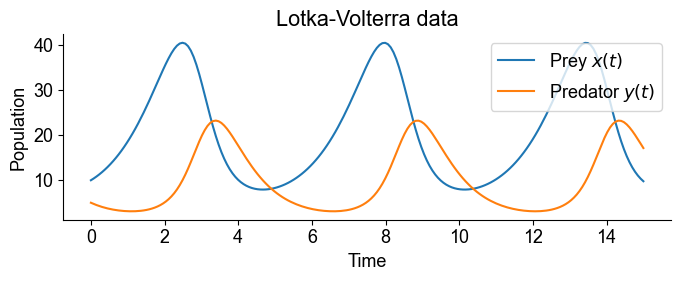

In [8]:
# ── True Lotka-Volterra parameters ───────────────────────────────────────────
ALPHA_TRUE = 1.00    # prey growth rate
BETA_TRUE  = 0.10    # predation rate
GAMMA_TRUE = 0.075   # predator conversion efficiency
DELTA_TRUE = 1.50    # predator death rate

# ── Initial conditions (treated as KNOWN) ─────────────────────────────────────
x0 = np.array([10.0, 5.0])   # [prey, predator]

# ── Tunable noise ─────────────────────────────────────────────────────────────
# NOISE_LEVEL = 0.0   → clean (no noise)
# NOISE_LEVEL = 0.05  → 5% of signal std  (mild)
# NOISE_LEVEL = 0.10  → 10%               (moderate)
# NOISE_LEVEL = 0.20  → 20%               (challenging)
NOISE_LEVEL = 0.05

# ── Generate observations ─────────────────────────────────────────────────────
t_obs = np.linspace(0, 15, 200)

def true_ode(t, z):
    x, y = z
    return [ALPHA_TRUE*x - BETA_TRUE*x*y,
            GAMMA_TRUE*x*y - DELTA_TRUE*y]

sol = solve_ivp(true_ode, [0, 15], x0, t_eval=t_obs, max_step=0.05)
x_clean, y_clean = sol.y[0], sol.y[1]

np.random.seed(7)
x_data = x_clean + NOISE_LEVEL * np.std(x_clean) * np.random.randn(len(t_obs))
y_data = y_clean + NOISE_LEVEL * np.std(y_clean) * np.random.randn(len(t_obs))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(t_obs, x_clean, 'C0-',  lw=1, alpha=0.4, label='True $x(t)$')
ax.plot(t_obs, y_clean, 'C1-',  lw=1, alpha=0.4, label='True $y(t)$')
ax.scatter(t_obs, x_data, s=4, c='C0', label=f'Observed $x$ (noise={NOISE_LEVEL})')
ax.scatter(t_obs, y_data, s=4, c='C1', label=f'Observed $y$ (noise={NOISE_LEVEL})')
ax.set(xlabel='Time', ylabel='Population', title='Lotka-Volterra — noisy observations')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()


## 3. Library of Basis Functions

Following SINDy, we define a fixed library of candidate terms:

$$\Phi(x, y) = \begin{bmatrix} 1 & x & y & xy & x^2 & y^2 \end{bmatrix}$$

We assume each equation is a **sparse linear combination** of these terms:

$$\dot{x} = \sum_{k=1}^{6} c_k^x \, \phi_k(x, y)$$
$$\dot{y} = \sum_{k=1}^{6} c_k^y \, \phi_k(x, y)$$

where most $c_k$ are zero. The true equations use only $x$ and $xy$ for $\dot{x}$,
and $xy$ and $y$ for $\dot{y}$.


In [9]:
TERM_NAMES = ['1', 'x', 'y', 'xy', 'x²', 'y²']
N_TERMS    = len(TERM_NAMES)

def library(x, y):
    """Evaluate all 6 basis functions at a single (x, y) point."""
    return np.array([1.0, x, y, x*y, x**2, y**2])

print('Library terms:', TERM_NAMES)
print('Example at (x=2, y=3):', library(2, 3))


Library terms: ['1', 'x', 'y', 'xy', 'x²', 'y²']
Example at (x=2, y=3): [1. 2. 3. 6. 4. 9.]


## 4. The Network: One Node Per Term

For each equation we have **6 nodes**, one per library term.
Each node $k$ holds a single learnable scalar:
$$\theta_k \in \mathbb{R} \quad \text{(logit)}$$

**Sparsity.** Term $k$ is active with probability
$$p_k = \sigma(\theta_k), \qquad z_k \sim \text{Bernoulli}(p_k)$$

**Coefficients.** Given the active terms, we solve for $\alpha$ via least squares:
$$\hat{\alpha}_z = \arg\min_{\alpha} \| \Theta_z \alpha - \dot{x}_{\text{data}} \|^2$$

where $\Theta_z$ is the library matrix with only the active columns,
and $\dot{x}_{\text{data}}$ is estimated from data by Savitzky-Golay smoothing.

We have **6 learnable parameters per equation** (logits only), **12 total**.

> **Connection to SINDy:** SINDy uses an $\ell_1$ (LASSO) penalty to select sparse terms;
> REINFORCE uses a reward signal and stochastic gradient ascent.
> Both then use least squares for the coefficient values.


In [10]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -15, 15)))

# ── Learnable logits: one per term, per equation (12 total) ──────────────────
np.random.seed(42)
theta_x = np.zeros(N_TERMS)   # starts at p=0.5 (no prior preference)
theta_y = np.zeros(N_TERMS)


## 5. Reward: Derivative Residual

Given masks $z_x, z_y$, we:

1. **Fit coefficients** via least squares on the numerical derivatives:
   $\hat{\alpha}_x = \arg\min_\alpha \|\Theta_{z_x} \alpha - \dot{x}\|^2$

2. **Compute reward** as the negative normalised residual, penalised for complexity:
$$R(z_x, z_y) = -\frac{\|\Theta_{z_x}\hat{\alpha}_x - \dot{x}\|^2}{\text{Var}(\dot{x})}
               -\frac{\|\Theta_{z_y}\hat{\alpha}_y - \dot{y}\|^2}{\text{Var}(\dot{y})}
               - \lambda(|z_x| + |z_y|)$$

The sparsity penalty $\lambda$ prefers equations with fewer active terms.
This reward is **fast** (no ODE integration) and gives a sharp signal:
the true 2+2 term structure is the unique global optimum.


In [11]:
# ── Smoothed numerical derivatives (Savitzky-Golay) ──────────────────────────
dt = t_obs[1] - t_obs[0]
dxdt_data = savgol_filter(x_data, window_length=11, polyorder=3, deriv=1, delta=dt)
dydt_data = savgol_filter(y_data, window_length=11, polyorder=3, deriv=1, delta=dt)

# ── Library matrix Θ  (N × 6) ─────────────────────────────────────────────────
Theta = np.column_stack([
    np.ones(len(t_obs)),
    x_data, y_data,
    x_data * y_data,
    x_data**2, y_data**2
])

LAMBDA = 0.05   # sparsity penalty per active term

def fit_and_reward(z_x, z_y):
    """
    Given binary masks z_x, z_y (length 6):
      1. Fit coefficients via least squares on the smoothed derivatives.
      2. Return reward = -(normalised residual) - lambda*(num active terms).
    """
    alpha_x = np.zeros(N_TERMS)
    alpha_y = np.zeros(N_TERMS)

    ix = z_x.astype(bool)
    if ix.any():
        coef, _, _, _ = np.linalg.lstsq(Theta[:, ix], dxdt_data, rcond=None)
        alpha_x[ix] = coef

    iy = z_y.astype(bool)
    if iy.any():
        coef, _, _, _ = np.linalg.lstsq(Theta[:, iy], dydt_data, rcond=None)
        alpha_y[iy] = coef

    res_x = np.mean((Theta @ alpha_x - dxdt_data)**2) / (np.var(dxdt_data) + 1e-10)
    res_y = np.mean((Theta @ alpha_y - dydt_data)**2) / (np.var(dydt_data) + 1e-10)

    return alpha_x, alpha_y, float(-(res_x + res_y) - LAMBDA*(z_x.sum() + z_y.sum()))


# ── Sanity check: does the true mask give a near-zero residual? ───────────────
z_xt = np.array([0,1,0,1,0,0], dtype=float)
z_yt = np.array([0,0,1,1,0,0], dtype=float)
ax_t, ay_t, r_t = fit_and_reward(z_xt, z_yt)
print('Sanity check — true mask, least-squares coefficients:')
print(f'  dx/dt:  ', '  '.join(f'{ax_t[k]:+.4f}·{TERM_NAMES[k]}' for k in range(N_TERMS) if z_xt[k]))
print(f'  dy/dt:  ', '  '.join(f'{ay_t[k]:+.4f}·{TERM_NAMES[k]}' for k in range(N_TERMS) if z_yt[k]))
print(f'  Reward = {r_t:.4f}  (penalty = {LAMBDA*4:.2f}; true residual ~ 0)')
print()
print('True parameters:')
print(f'  dx/dt = +{ALPHA_TRUE}·x  -{BETA_TRUE}·xy')
print(f'  dy/dt = -{DELTA_TRUE}·y  +{GAMMA_TRUE}·xy')


Sanity check — true mask, least-squares coefficients:
  dx/dt:   +0.9989·x  -0.0999·xy
  dy/dt:   -1.4972·y  +0.0749·xy
  Reward = -0.2000  (penalty = 0.20; true residual ~ 0)

True parameters:
  dx/dt = +1.0·x  -0.1·xy
  dy/dt = -1.5·y  +0.075·xy


## 6. REINFORCE: Learning Structure

We use **REINFORCE** (Williams 1992) to learn which terms belong in each equation.
At each iteration we draw a batch of masks, fit coefficients via least squares for each,
integrate the ODE, and compute rewards.

The only parameters being learned are the logits $\theta_k$:

$$\theta_k \leftarrow \theta_k + \eta \cdot \frac{1}{B}\sum_{b=1}^{B}\,(R^{(b)} - \bar{R}) \cdot (z_k^{(b)} - p_k)$$

where $\bar{R}$ is the batch mean reward (baseline), and $B$ is the batch size.

**Relationship to SINDy:** SINDy uses LASSO (a $\ell_1$ penalty) to find sparse structure.
REINFORCE uses a reward signal and gradient ascent. Both then use least squares for the coefficients.


In [13]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
N_ITER      = 800
BATCH       = 64
ETA_TH      = 0.12   # learning rate for logits
CLIP        = 3.0
PRINT_EVERY = 10

# Update the sparsity penalty in fit_and_reward
LAMBDA = 0.10   # prefer fewer active terms

# ── Redefine reward with updated LAMBDA ───────────────────────────────────────
def fit_and_reward(z_x, z_y):
    alpha_x = np.zeros(N_TERMS)
    alpha_y = np.zeros(N_TERMS)
    ix = z_x.astype(bool)
    if ix.any():
        coef, _, _, _ = np.linalg.lstsq(Theta[:, ix], dxdt_data, rcond=None)
        alpha_x[ix] = coef
    iy = z_y.astype(bool)
    if iy.any():
        coef, _, _, _ = np.linalg.lstsq(Theta[:, iy], dydt_data, rcond=None)
        alpha_y[iy] = coef
    res_x = np.mean((Theta @ alpha_x - dxdt_data)**2) / (np.var(dxdt_data) + 1e-10)
    res_y = np.mean((Theta @ alpha_y - dydt_data)**2) / (np.var(dydt_data) + 1e-10)
    return alpha_x, alpha_y, float(-(res_x + res_y) - LAMBDA*(z_x.sum() + z_y.sum()))

# ── Reset logits ───────────────────────────────────────────────────────────────
np.random.seed(42)
theta_x = np.zeros(N_TERMS)
theta_y = np.zeros(N_TERMS)

best_reward = -np.inf
best_result = None
reward_hist = []

def active_str(z, alpha):
    parts = [f'{alpha[k]:+.3f}·{TERM_NAMES[k]}' for k in range(N_TERMS) if z[k] > 0.5]
    return '  '.join(parts) if parts else '(none)'

print(f'REINFORCE — {N_ITER} iterations, batch {BATCH}')
print(f'Learnable parameters: {2*N_TERMS} logits (structure only)')
print('-'*70)
print(f'{"Iter":>6}  {"BestR":>7}  {"BatchR":>7}  Best equations found so far')
print('-'*70)

for it in range(N_ITER):
    p_x = sigmoid(theta_x)
    p_y = sigmoid(theta_y)

    rews = []; z_xs = []; z_ys = []; a_xs = []; a_ys = []

    for _ in range(BATCH):
        z_x = (np.random.rand(N_TERMS) < p_x).astype(float)
        z_y = (np.random.rand(N_TERMS) < p_y).astype(float)
        ax, ay, r = fit_and_reward(z_x, z_y)
        rews.append(r); z_xs.append(z_x); z_ys.append(z_y)
        a_xs.append(ax); a_ys.append(ay)

    rews = np.array(rews)
    adv  = rews - rews.mean()   # baseline subtraction

    # REINFORCE gradient ascent on logits
    g_x = sum(adv[i] * (z_xs[i] - p_x) for i in range(BATCH)) / BATCH
    g_y = sum(adv[i] * (z_ys[i] - p_y) for i in range(BATCH)) / BATCH
    theta_x += ETA_TH * np.clip(g_x, -CLIP, CLIP)
    theta_y += ETA_TH * np.clip(g_y, -CLIP, CLIP)

    best_i = np.argmax(rews)
    if rews[best_i] > best_reward:
        best_reward = rews[best_i]
        best_result = (z_xs[best_i].copy(), a_xs[best_i].copy(),
                       z_ys[best_i].copy(), a_ys[best_i].copy())

    reward_hist.append(rews.max())

    if (it + 1) % PRINT_EVERY == 0:
        zx_b, acx, zy_b, acy = best_result
        print(f'{it+1:6d}  {best_reward:7.4f}  {rews.mean():7.4f}')
        print(f'                        dx/dt = {active_str(zx_b, acx)}')
        print(f'                        dy/dt = {active_str(zy_b, acy)}')

print('-'*70)
print('Done.')


REINFORCE — 800 iterations, batch 64
Learnable parameters: 12 logits (structure only)
----------------------------------------------------------------------
  Iter    BestR   BatchR  Best equations found so far
----------------------------------------------------------------------
    10  -0.5000  -1.0906
                        dx/dt = +1.000·x  -0.100·xy  -0.000·x²
                        dy/dt = -1.497·y  +0.075·xy
    20  -0.5000  -1.1661
                        dx/dt = +1.000·x  -0.100·xy  -0.000·x²
                        dy/dt = -1.497·y  +0.075·xy
    30  -0.5000  -1.2463
                        dx/dt = +1.000·x  -0.100·xy  -0.000·x²
                        dy/dt = -1.497·y  +0.075·xy
    40  -0.5000  -1.1675
                        dx/dt = +0.998·x  -0.100·xy  -0.000·y²
                        dy/dt = -1.497·y  +0.075·xy
    50  -0.5000  -1.1426
                        dx/dt = +0.998·x  -0.100·xy  -0.000·y²
                        dy/dt = -1.497·y  +0.075·xy
    60  -0.5000  -

## 7. Results


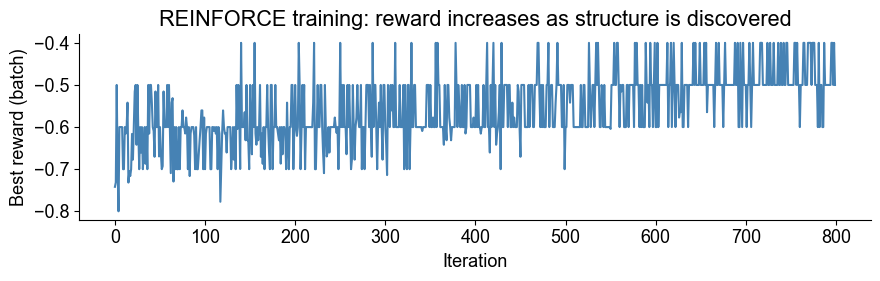

In [14]:
# ── Training curve ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(reward_hist, color='steelblue', lw=1.5)
ax.set_xlabel('Iteration'); ax.set_ylabel('Best reward (batch)')
ax.set_title('REINFORCE training: reward increases as structure is discovered')
plt.tight_layout(); plt.show()


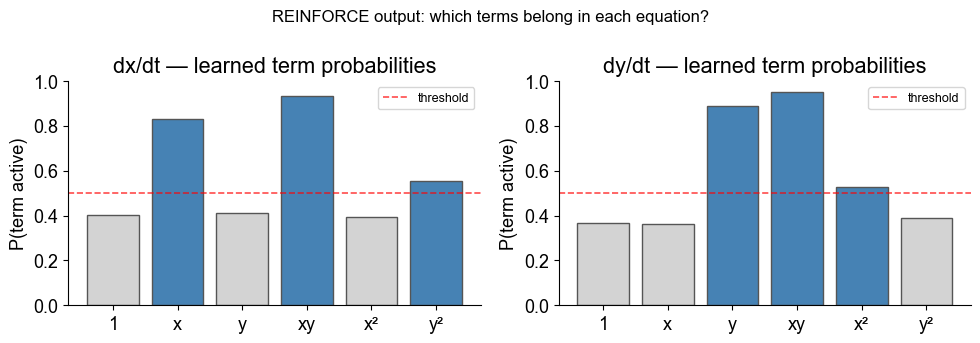

Terms with p > 0.5 for dx/dt: ['x', 'xy', 'y²']
Terms with p > 0.5 for dy/dt: ['y', 'xy', 'x²']

Note: the best-found sample (stored in best_result) gives the final equation
regardless of the exact threshold — see next cell.


In [15]:
# ── Learned term probabilities ────────────────────────────────────────────────
p_x_final = sigmoid(theta_x)
p_y_final = sigmoid(theta_y)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

for ax_plot, p_final, label in zip(axes,
                                    [p_x_final, p_y_final],
                                    ['dx/dt', 'dy/dt']):
    colors = ['steelblue' if p > 0.5 else 'lightgray' for p in p_final]
    ax_plot.bar(TERM_NAMES, p_final, color=colors, edgecolor='#555')
    ax_plot.axhline(0.5, color='red', lw=1.2, linestyle='--', alpha=0.7, label='threshold')
    ax_plot.set_ylim(0, 1)
    ax_plot.set_ylabel('P(term active)')
    ax_plot.set_title(f'{label} — learned term probabilities')
    ax_plot.legend(fontsize=9)

plt.suptitle('REINFORCE output: which terms belong in each equation?', fontsize=12)
plt.tight_layout()
plt.show()

print('Terms with p > 0.5 for dx/dt:', [TERM_NAMES[k] for k in range(N_TERMS) if p_x_final[k] > 0.5])
print('Terms with p > 0.5 for dy/dt:', [TERM_NAMES[k] for k in range(N_TERMS) if p_y_final[k] > 0.5])
print()
print('Note: the best-found sample (stored in best_result) gives the final equation')
print('regardless of the exact threshold — see next cell.')


In [16]:
# ── Recovered equations ───────────────────────────────────────────────────────
z_x_best, a_x_best, z_y_best, a_y_best = best_result

def print_equation(label, z, alpha):
    terms = [f'{alpha[k]:+.4f}·{TERM_NAMES[k]}' for k in range(N_TERMS) if z[k] > 0.5]
    print(f'  {label} = ' + '  '.join(terms) if terms else f'  {label} = 0')

print('=== Recovered Equations ===')
print_equation('dx/dt', z_x_best, a_x_best)
print_equation('dy/dt', z_y_best, a_y_best)
print()
print('=== True Equations ===')
print(f'  dx/dt = +{ALPHA_TRUE}·x  -{BETA_TRUE}·xy')
print(f'  dy/dt = -{DELTA_TRUE}·y  +{GAMMA_TRUE}·xy')


=== Recovered Equations ===
  dx/dt = +0.9989·x  -0.0999·xy
  dy/dt = -1.4972·y  +0.0749·xy

=== True Equations ===
  dx/dt = +1.0·x  -0.1·xy
  dy/dt = -1.5·y  +0.075·xy


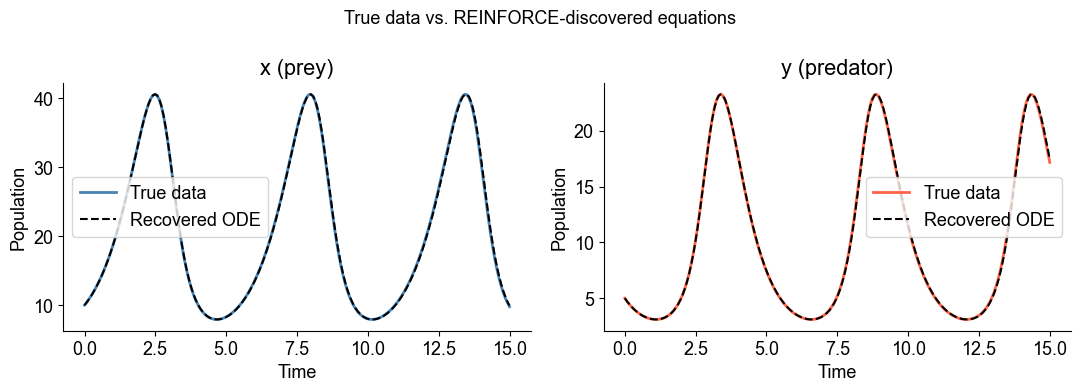

In [17]:
# ── Compare recovered ODE to true data ───────────────────────────────────────
from scipy.integrate import solve_ivp

def recovered_ode(t, z):
    x, y = max(z[0], 0.), max(z[1], 0.)
    phi = library(x, y)
    return [np.dot(a_x_best, phi), np.dot(a_y_best, phi)]

sol_rec = solve_ivp(recovered_ode, [0, 15], x0, t_eval=t_obs, max_step=0.1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
labels = ['x (prey)', 'y (predator)']
colors = ['steelblue', 'tomato']
data_arrays = [x_data, y_data]
rec_arrays  = [sol_rec.y[0], sol_rec.y[1]] if sol_rec.success else [np.nan*t_obs, np.nan*t_obs]

for ax, label, color, data, rec in zip(axes, labels, colors, data_arrays, rec_arrays):
    ax.plot(t_obs, data, color=color, lw=2, label='True data')
    ax.plot(t_obs, rec, 'k--', lw=1.5, label='Recovered ODE')
    ax.set(xlabel='Time', ylabel='Population', title=label)
    ax.legend()

plt.suptitle('True data vs. REINFORCE-discovered equations', fontsize=13)
plt.tight_layout()
plt.show()


## 8. Discussion

**What we learned:**

- $\theta_k$: which terms belong in each equation (the *structure*).
- Coefficients are computed analytically by least squares — REINFORCE never touches them.

**Comparison with SINDy:**
Both methods fix the same polynomial library and use least squares for coefficients.
SINDy enforces sparsity via an $\ell_1$ (LASSO) penalty solved by convex optimization.
REINFORCE uses stochastic search — it explores randomly, then reinforces structure choices
that yield low derivative residuals.

**Why the learned probabilities are not 0/1:**
REINFORCE learns slowly because the reward landscape is relatively flat — once the key terms
($x$ and $xy$ for $\dot{x}$) are found, adding an extra term barely changes the reward.
The *best-found sample* across all iterations converges to the correct equation well before
the policy probabilities fully converge.  Real DSO systems use entropy regularization,
more iterations, or symbolic beam search to sharpen this.

**Exercises:**
1. Change the true parameters (e.g.~$\beta=0.2$) and re-run.
2. Add a quadratic term $x^2$ to the true ODE and see if REINFORCE recovers it.
3. Increase `LAMBDA` and observe: does the algorithm prefer sparser equations? Does it miss terms?
4. Compare the recovered coefficients with those from running SINDy (`pysindy` library).


---
## 9. Noise Robustness

How much measurement noise can REINFORCE tolerate before the structure breaks down?

We add Gaussian noise scaled to a fraction of the signal standard deviation:
$$x^{\text{obs}}_t = x_t + \varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0,\, (\eta\cdot\sigma_x)^2)$$
where $\eta$ is `NOISE_LEVEL`. We then run the full REINFORCE algorithm and check
whether the discovered structure matches the true equations.

**Key bottleneck:** Savitzky-Golay smoothing recovers derivatives from noisy data,
but only up to a point. When noise overwhelms the signal in the derivative estimate,
the reward signal becomes uninformative and REINFORCE fails to find the right structure.


In [ ]:
def run_reinforce(noise_level, seed=42, n_iter=800, batch=64):
    """Full REINFORCE pipeline for a given noise level. Returns best result."""
    np.random.seed(7)
    x_n = x_clean + noise_level * np.std(x_clean) * np.random.randn(len(t_obs))
    y_n = y_clean + noise_level * np.std(y_clean) * np.random.randn(len(t_obs))

    dxdt_n = savgol_filter(x_n, window_length=11, polyorder=3, deriv=1, delta=dt)
    dydt_n = savgol_filter(y_n, window_length=11, polyorder=3, deriv=1, delta=dt)
    Th = np.column_stack([np.ones(len(t_obs)), x_n, y_n,
                          x_n*y_n, x_n**2, y_n**2])

    def reward(zx, zy):
        ax = np.zeros(N_TERMS); ay = np.zeros(N_TERMS)
        if zx.any(): c,_,_,_ = np.linalg.lstsq(Th[:,zx.astype(bool)], dxdt_n, rcond=None); ax[zx.astype(bool)] = c
        if zy.any(): c,_,_,_ = np.linalg.lstsq(Th[:,zy.astype(bool)], dydt_n, rcond=None); ay[zy.astype(bool)] = c
        rx = np.mean((Th@ax - dxdt_n)**2) / (np.var(dxdt_n) + 1e-10)
        ry = np.mean((Th@ay - dydt_n)**2) / (np.var(dydt_n) + 1e-10)
        return ax, ay, -(rx + ry) - LAMBDA*(zx.sum() + zy.sum())

    np.random.seed(seed)
    th_x = np.zeros(N_TERMS); th_y = np.zeros(N_TERMS)
    best_r = -np.inf; best = None
    for _ in range(n_iter):
        p_x = sigmoid(th_x); p_y = sigmoid(th_y)
        rews, ZX, ZY, AX, AY = [], [], [], [], []
        for _ in range(batch):
            zx = (np.random.rand(N_TERMS) < p_x).astype(float)
            zy = (np.random.rand(N_TERMS) < p_y).astype(float)
            ax, ay, r = reward(zx, zy)
            rews.append(r); ZX.append(zx); ZY.append(zy); AX.append(ax); AY.append(ay)
        rews = np.array(rews); adv = rews - rews.mean()
        th_x += ETA_TH * np.clip(sum(adv[i]*(ZX[i]-p_x) for i in range(batch))/batch, -CLIP, CLIP)
        th_y += ETA_TH * np.clip(sum(adv[i]*(ZY[i]-p_y) for i in range(batch))/batch, -CLIP, CLIP)
        bi = np.argmax(rews)
        if rews[bi] > best_r: best_r = rews[bi]; best = (ZX[bi].copy(), AX[bi].copy(), ZY[bi].copy(), AY[bi].copy())
    return best

# ── Sweep ─────────────────────────────────────────────────────────────────────
noise_levels = [0.0, 0.05, 0.10, 0.20, 0.30, 0.50]
results = []
for eta in noise_levels:
    zx, axf, zy, ayf = run_reinforce(eta)
    correct = (set(k for k in range(N_TERMS) if zx[k]) == {1,3} and
               set(k for k in range(N_TERMS) if zy[k]) == {2,3})
    dx_str = ' '.join(f'{axf[k]:+.3f}·{TERM_NAMES[k]}' for k in range(N_TERMS) if zx[k]) or '(none)'
    dy_str = ' '.join(f'{ayf[k]:+.3f}·{TERM_NAMES[k]}' for k in range(N_TERMS) if zy[k]) or '(none)'
    results.append({'noise': eta, 'correct': correct, 'dx': dx_str, 'dy': dy_str,
                    'ax': axf.copy(), 'ay': ayf.copy(), 'zx': zx.copy(), 'zy': zy.copy()})
    tag = '✓ correct' if correct else '✗ wrong'
    print(f'Noise {eta:4.0%}  [{tag}]  dx/dt = {dx_str}')
    print(f'                      dy/dt = {dy_str}')


In [ ]:
# ── Coefficient recovery vs noise ─────────────────────────────────────────────
true_vals = {'x': ALPHA_TRUE, 'xy_x': -BETA_TRUE, 'y': -DELTA_TRUE, 'xy_y': GAMMA_TRUE}
noises = [r['noise'] for r in results]

def coeff(r, eq, term_idx):
    arr = r['ax'] if eq == 'x' else r['ay']
    return arr[term_idx] if (r['zx'][term_idx] if eq=='x' else r['zy'][term_idx]) else np.nan

alpha_x_vals  = [coeff(r, 'x', 1) for r in results]   # coeff of x in dx/dt
beta_xy_vals  = [coeff(r, 'x', 3) for r in results]   # coeff of xy in dx/dt
delta_y_vals  = [coeff(r, 'y', 2) for r in results]   # coeff of y in dy/dt
gamma_xy_vals = [coeff(r, 'y', 3) for r in results]   # coeff of xy in dy/dt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
pct = [n*100 for n in noises]

axes[0].plot(pct, alpha_x_vals,  'o-', label=f'α (x coeff, true={ALPHA_TRUE})')
axes[0].plot(pct, beta_xy_vals,  's-', label=f'β (xy coeff, true={-BETA_TRUE})')
axes[0].axhline(ALPHA_TRUE,  color='C0', lw=0.8, ls='--', alpha=0.5)
axes[0].axhline(-BETA_TRUE,  color='C1', lw=0.8, ls='--', alpha=0.5)
axes[0].set(xlabel='Noise level (%)', ylabel='Recovered coefficient',
            title='dx/dt coefficients vs noise')
axes[0].legend(); axes[0].set_xticks(pct)

axes[1].plot(pct, delta_y_vals,  'o-', color='C2', label=f'δ (y coeff, true={-DELTA_TRUE})')
axes[1].plot(pct, gamma_xy_vals, 's-', color='C3', label=f'γ (xy coeff, true={GAMMA_TRUE})')
axes[1].axhline(-DELTA_TRUE,  color='C2', lw=0.8, ls='--', alpha=0.5)
axes[1].axhline(GAMMA_TRUE,   color='C3', lw=0.8, ls='--', alpha=0.5)
axes[1].set(xlabel='Noise level (%)', ylabel='Recovered coefficient',
            title='dy/dt coefficients vs noise')
axes[1].legend(); axes[1].set_xticks(pct)

# shade the failure zone
for ax in axes:
    ax.axvspan(40, 55, color='red', alpha=0.08, label='structure breaks')
    ax.set_xlim(-2, 55)

plt.suptitle('REINFORCE recovers correct structure up to ~30% noise,\n'
             'coefficients degrade gracefully before the cliff at 50%', fontsize=11)
plt.tight_layout(); plt.show()

print('Summary:')
for r in results:
    tag = '✓' if r['correct'] else '✗'
    print(f"  {r['noise']:4.0%} noise  {tag}  {'Correct structure' if r['correct'] else 'Wrong structure'}")


---
## 10. From Here to Deep Symbolic Optimization (DSO)

### What we just built

We searched over **4,096 possible equation pairs** — every binary mask over 6 library terms
for two equations ($2^6 \times 2^6 = 4{,}096$). REINFORCE guided that search efficiently
without checking all combinations.

### Why 4,096 is a special case

The library size $|\Phi|$ grows fast with the number of variables $n$ and polynomial degree $d$:

| Variables $n$ | Degree $d$ | Library size $|\Phi|$ | Search space (2 eqs) |
|:---:|:---:|:---:|:---:|
| 2 | 2 | 6 | $2^{12} = 4{,}096$ ← *we are here* |
| 5 | 3 | 56 | $2^{112} \approx 5 \times 10^{33}$ |
| 10 | 3 | 286 | $2^{572}$ — astronomical |
| any | any | $\infty$ | — with non-polynomial terms |

The moment you allow $\sin(x)$, $e^{-x}$, $x/y$, or any arbitrary composition,
the library becomes **infinite**. A fixed mask over a polynomial basis no longer works.

### Three methods, one problem

The table below compares the three approaches on the same task — recovering sparse ODEs from data.

|  | **SINDy** | **Our method (REINFORCE+LS)** | **DSO** |
|---|---|---|---|
| **Library** | Fixed polynomial basis | Fixed polynomial basis | None — any expression |
| **Structure search** | $\ell_1$ (LASSO) thresholding | REINFORCE over binary masks | REINFORCE over expression trees |
| **Policy** | — (convex optimization) | 12 logits (Bernoulli per term) | RNN (LSTM, ~256 units) |
| **Action space** | $4{,}096$ sparse subsets | $4{,}096$ binary masks | All symbolic expressions |
| **Coefficients** | Least squares | Least squares | Optimized jointly |
| **Reward / loss** | LASSO residual | Derivative residual | **ODE trajectory fit** |
| **Derivatives needed?** | Yes — and this is the bottleneck | Yes — same bottleneck | **No** — integrates ODE forward |
| **Noise tolerance** | Moderate (SG smoothing) | Moderate (same SG bottleneck) | **High** — no derivative needed |
| **Extrapolates beyond polynomials?** | No | No | **Yes** — $\sin$, $e^{-x}$, $x/y$, … |
| **Scales to large systems?** | Moderately (library grows fast) | Poor ($2^{KN}$ blows up) | Better (but tree depth is a limit) |
| **Training cost** | Cheap (convex) | Cheap (12 parameters) | Expensive (RNN + many rollouts) |
| **Interpretability** | High | High | High (output is an expression) |

### What DSO does instead

**Deep Symbolic Optimization** (Petersen et al., *ICLR 2021*) replaces the binary mask
with a **recurrent neural network (RNN)** that generates symbolic expressions token by token —
like writing code character by character:

$$\text{expression} = \underbrace{\text{mul}}_{\times} \underbrace{\text{add}}_{+}
\underbrace{x}_{x} \underbrace{\text{sin}}_{\sin} \underbrace{y}_{y} \underbrace{1.3}_{c}$$

The key insight: **the training algorithm is still REINFORCE** — exactly what you learned here.

### Does DSO actually win?

SINDy gets a lot of attention, but the benchmark study by La Cava et al. (2021) evaluated
14 symbolic regression methods head-to-head on hundreds of tasks.
DSO ranked among the **top performers** on recovery of the true equation,
especially on tasks with transcendental functions ($\sin$, $\exp$) where
SINDy's fixed polynomial library simply cannot express the answer.

On *purely polynomial* systems like Lotka-Volterra, SINDy is competitive and much faster.
On systems with non-polynomial terms — or under heavy noise where derivative estimation fails —
DSO's trajectory-based reward is the decisive advantage.

> The noise cliff we observed at 50% is a consequence of Savitzky-Golay, not REINFORCE.
> DSO sidesteps it by never computing a derivative.

### The takeaway for this tutorial

> **REINFORCE is the engine.** The policy can be 12 numbers or a 256-unit LSTM;
> the reward can be a derivative residual or an ODE trajectory match.
> The algorithm that updates the policy is the same in both cases.

### Further reading
- Petersen et al. (2021). *Deep symbolic regression: Recovering mathematical expressions
  from data via risk-seeking policy gradients.* ICLR 2021. [[paper]](https://arxiv.org/abs/1912.04871)
- La Cava et al. (2021). *Contemporary symbolic regression methods and their relative
  performance.* NeurIPS 2021 (Datasets & Benchmarks). [[paper]](https://arxiv.org/abs/2107.14351) — the benchmark that shows where DSO wins
- Brunton et al. (2016). *Discovering governing equations from data by sparse identification
  of nonlinear dynamical systems.* PNAS. [[paper]](https://www.pnas.org/doi/10.1073/pnas.1517384113) — the original SINDy paper
- Williams (1992). *Simple statistical gradient-following algorithms for connectionist
  reinforcement learning.* — the original REINFORCE paper.
